
              Meaning Morphos - Automatic Analysis Mode

Loaded 38 words → 114 quiz items ready.


--- Round 1 of 5 ---
MODERN AMERICAN (2026)
Definition: Releasing gases microbes or particles into the atmosphere to change planetary conditions
  1. lag
  2. server
  3. seeding
  4. dial

Your answer (1-4): 3
✅ Correct! +10 points (Total: 10)

--- Semantic Analysis ---

🧠 Sense Map for 'seeding' (Grok-estimated years visible on nodes)



📈 Google Ngram + Sense Emergence Markers for 'seeding'


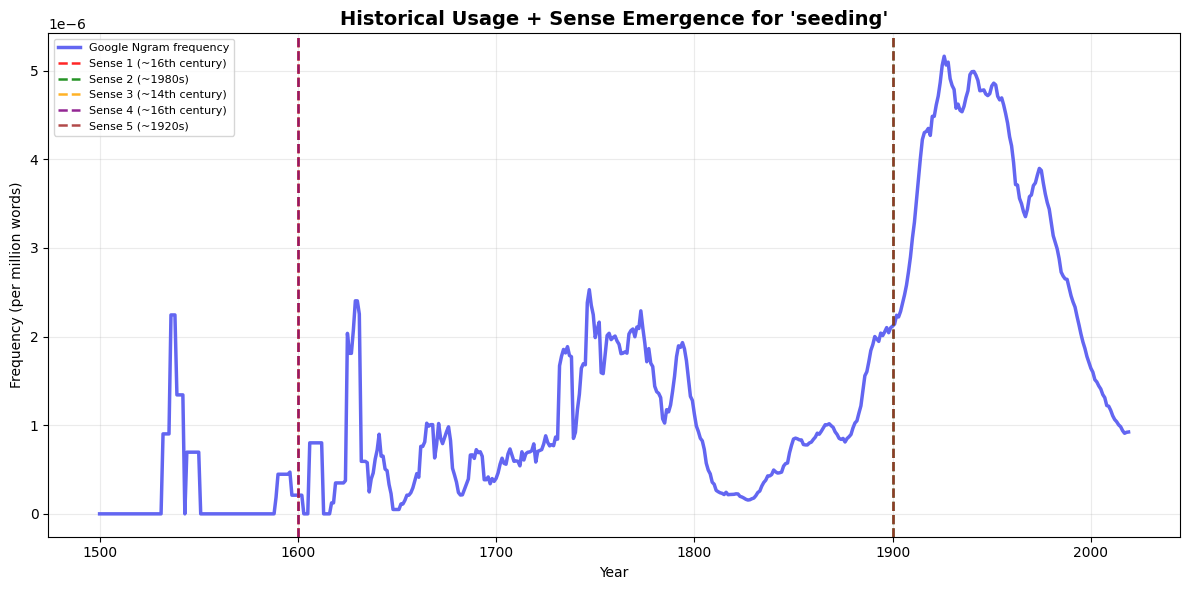


🧠 Grok AI's Educational Insight:
Hey, let's dive into the fascinating evolution of the word "seeding"! By 2026, its meaning has shifted dramatically from its original agricultural sense of planting seeds to a futuristic concept of "releasing gases, microbes, or particles into the atmosphere to change planetary conditions," often tied to geoengineering or climate control. This change likely emerged in the late 20th or early 21st century, driven by rapid advancements in technology and growing concerns about climate change, pushing scientists and society to explore radical solutions like cloud seeding or atmospheric manipulation. Understanding this shift matters because it reflects how language adapts to capture cutting-edge ideas and urgent global challenges, showing us the power of words to mirror our world’s evolving priorities.

🌳 WordNet Ontology for 'seeding':
  Sense: go to seed; shed seeds
    → spill
  Sense: help (an enterprise) in its early stages of development by providing s

KeyboardInterrupt: Interrupted by user

In [2]:
# Install required libraries for the game to run in Google Colab
!pip install colorama requests pandas nltk matplotlib openai plotly networkx -q

# Import the colorama library to enable colored text output in the terminal
from colorama import init, Fore

# Initialize colorama so that colored text works correctly in Google Colab terminal
init(autoreset=True)

# Import the requests library to send HTTP requests and download data from the internet
import requests

# Import the pandas library to read, manipulate, and analyze tabular data such as CSV files
import pandas as pd

# Import the random library to generate random numbers and shuffle lists for quiz options
import random

# Import the io library to treat string data as file-like objects for reading CSV content
import io

# Import matplotlib pyplot to create and display plots such as Ngram graphs and timelines
import matplotlib.pyplot as plt

# Import the nltk library for natural language processing tasks including WordNet access
import nltk

# Import wordnet from the nltk corpus to access lexical database for word senses and definitions
from nltk.corpus import wordnet as wn

# Import the OpenAI client to connect to external AI APIs including the Grok model
from openai import OpenAI

# Import plotly graph objects to create interactive visualizations such as sense maps
import plotly.graph_objects as go

# Import networkx to create and manipulate graph structures for the sense map visualization
import networkx as nx

# Import warnings module and suppress unnecessary warning messages during execution
import warnings
warnings.filterwarnings('ignore')

# Download the WordNet lexical database required for retrieving word senses and definitions
nltk.download('wordnet', quiet=True)

# Download the Open Multilingual WordNet data to support additional language resources if needed
nltk.download('omw-1.4', quiet=True)

# Store the provided Grok API key as a string variable for authentication
GROK_API_KEY = "UPLOADYOURGROKKEYHERE"

# Create an OpenAI client instance configured to use the Grok API endpoint instead of OpenAI
client = OpenAI(api_key=GROK_API_KEY, base_url="https://api.x.ai/v1")

# Define a function to download and prepare the game data from a remote CSV file on GitHub
def load_game_data_from_github():
    # Specify the raw GitHub URL where the CSV file containing word data is stored
    url = "https://raw.githubusercontent.com/Isuriv/MeaningMorphos/main/tech_words_major_semantic_shifts_with_mars.csv"
    # Display a message to inform the user that data is being downloaded from the internet
    print("Downloading game data from GitHub...")
    # Send a GET request to the specified URL to retrieve the CSV file content
    response = requests.get(url)
    # Convert the response text into a pandas DataFrame by treating the text as a file object
    df = pd.read_csv(io.StringIO(response.text))
    # Extract all words from the DataFrame into a list for use in generating quiz options
    all_words = df['word'].tolist()
    # Initialize an empty list to store all generated quiz items for the game
    GAME_DATA = []
    # Iterate through each row in the DataFrame to create quiz entries for different time periods
    for _, row in df.iterrows():
        # Convert the word value from the current row into a string to ensure consistent data type
        word = str(row['word'])
        # Create and append a quiz item representing the word meaning in the year 1550 using the old definition
        GAME_DATA.append(
            {
                "era": "1550",
                "word": word,
                "definition": str(row['old_definition']),
                "correct": word,
                "points": 10,
            }
        )
        # Create and append a quiz item representing the word meaning in the year 2026 using the modern definition
        GAME_DATA.append(
            {
                "era": "2026",
                "word": word,
                "definition": str(row['modern_definition']),
                "correct": word,
                "points": 10,
            }
        )
        # Retrieve the future note from the row or fall back to the modern definition if notes are missing
        future_note = str(row.get('notes', row['modern_definition']))
        # Create and append a quiz item representing the word meaning in the year 2526 with a Martian future context
        GAME_DATA.append(
            {
                "era": "2526",
                "word": word,
                "definition": f"In 2526 Martian colonies, this evolved to mean: {future_note}",
                "correct": word,
                "points": 15,
            }
        )
    # Display a summary message showing how many words and total quiz items were successfully loaded
    print(f"Loaded {len(df)} words → {len(GAME_DATA)} quiz items ready.\n")
    # Return the complete game data list, the original DataFrame, and the list of all words
    return GAME_DATA, df, all_words


# Define a function to generate a list of multiple choice options including the correct answer
def generate_options(correct, all_words, num=4):
    # Begin the options list by including the correct answer as the first element
    options = [correct]
    # Continue adding incorrect options until the desired number of options is reached
    while len(options) < num:
        # Randomly select a candidate word from the full list of available words
        candidate = random.choice(all_words)
        # Add the candidate only if it is not already present in the current options list
        if candidate not in options:
            options.append(candidate)
    # Randomly rearrange the order of options so the correct answer is not always in the same position
    random.shuffle(options)
    # Return the shuffled list of options to be presented to the player
    return options


# Define a function to retrieve the modern definition of a word using the WordNet lexical database
def get_modern_definition(word):
    # Retrieve all synsets associated with the given word from WordNet
    synsets = wn.synsets(word)
    # Check if at least one synset exists for the word
    if synsets:
        # Return the definition of the first synset as the modern meaning
        return synsets[0].definition()
    # Return a default message if no definition is found in WordNet
    return "No WordNet definition found."


# Define a function to fetch and display the Google Ngram frequency trend for a given word
def get_ngram_trend(word):
    # Construct the API URL to request frequency data for the word between the years 1500 and 2019
    url = f"https://books.google.com/ngrams/json?content={word}&year_start=1500&year_end=2019&corpus=26"
    # Attempt to retrieve and process the Ngram data from the Google API
    try:
        # Send a GET request to the constructed URL with a timeout limit to prevent hanging
        response = requests.get(url, timeout=12)
        # Convert the JSON response into a Python dictionary
        data = response.json()
        # Check if the response contains no data or is empty
        if not data or len(data) == 0:
            # Inform the user that the word appears to be new or extremely rare in historical texts
            print(
                Fore.YELLOW
                + f"\n📊 '{word}' appears to be a **new or very rare word** in historical records."
            )
            # Exit the function early since there is no data to plot
            return
        # Extract the frequency time series values from the first result in the response
        timeseries = data[0]['timeseries']
        # Generate a list of years corresponding to the time series data range
        years = list(range(1500, 2020))
        # Create a new figure with specified dimensions for the plot
        plt.figure(figsize=(10, 5))
        # Plot the frequency values against the years using a distinct color and line width
        plt.plot(years, timeseries, color='#6366f1', linewidth=2.5)
        # Set the title of the plot to indicate the word and time range being displayed
        plt.title(
            f"Historical Usage of '{word}' (1500–2019)", fontsize=14, fontweight='bold'
        )
        # Label the x-axis to represent the time dimension
        plt.xlabel("Year")
        # Label the y-axis to represent frequency normalized per million words
        plt.ylabel("Frequency (per million words)")
        # Add a light grid to the plot for improved readability of values
        plt.grid(True, alpha=0.3)
        # Adjust the layout to prevent labels from overlapping or being cut off
        plt.tight_layout()
        # Display the completed plot to the user
        plt.show()
        # Identify the year with the highest frequency value in the time series
        peak_year = years[timeseries.index(max(timeseries))]
        # Print the year of peak usage in blue text for emphasis
        print(Fore.BLUE + f"📈 Peak usage year: {peak_year}")
    # Handle any exceptions that occur during the API request or plotting process
    except:
        # Inform the user that the Ngram data could not be retrieved due to an error
        print(Fore.RED + "Could not load Ngram data.")


# Define a function to display WordNet ontology information including hypernyms for a given word
def show_wordnet_ontology(word):
    # Attempt to retrieve and display WordNet data without crashing the program on errors
    try:
        # Retrieve all synsets for the specified word from the WordNet database
        synsets = wn.synsets(word)
        # Check if no synsets were found for the word
        if not synsets:
            # Inform the user that no WordNet data exists for the given word
            print(Fore.YELLOW + f"No WordNet data for '{word}'")
            # Exit the function early
            return
        # Print a colored header indicating the start of the WordNet ontology section
        print(Fore.GREEN + f"\n🌳 WordNet Ontology for '{word}':")
        # Iterate through the first two synsets to display limited but relevant information
        for syn in synsets[:2]:
            # Print the definition of the current sense
            print(f"  Sense: {syn.definition()}")
            # Iterate through the first three hypernyms of the current synset
            for h in syn.hypernyms()[:3]:
                # Print the primary lemma name of each hypernym as a broader category
                print(f"    → {h.lemma_names()[0]}")
    # Catch any exceptions that occur during WordNet processing
    except:
        # Display an error message in red text if WordNet data cannot be retrieved
        print(Fore.RED + "WordNet error.")


# Define a function to obtain an educational explanation of semantic change from the Grok model
def get_grok_semantic_change_explanation(word, era, old_def):
    # Construct a detailed prompt instructing Grok to explain the semantic shift in educational terms
    prompt = f"""You are a linguistics professor explaining semantic change to a student.\n\nWord: "{word}"\nTime period shown: {era}\nDefinition shown to student: "{old_def}"\n\nIn 3-4 clear educational sentences, explain:\n- When this word's meaning changed significantly\n- What historical, technological, or cultural reason caused the shift\n- Why this change matters\n\nKeep it engaging and easy to understand."""
    # Attempt to send the prompt to the Grok model and retrieve a response
    try:
        # Call the Grok API using the grok-3 model with the constructed prompt
        response = client.chat.completions.create(
            model="grok-3",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7,
            max_tokens=280,
        )
        # Print a colored header indicating that the following text is Grok's insight
        print(Fore.BLUE + "\n🧠 Grok AI's Educational Insight:")
        # Print the content of the response generated by the Grok model
        print(response.choices[0].message.content.strip())
    # Handle any exceptions that occur during the API call
    except Exception as e:
        # Display the specific error message in red text
        print(Fore.RED + f"Grok API error: {e}")


# Define a function to create and display an interactive sense map with estimated years on the nodes
def show_sense_map_with_years(word):
    # Print a colored header announcing the start of the sense map visualization
    print(Fore.CYAN + f"\n🧠 Sense Map for '{word}' (Grok-estimated years visible on nodes)")
    # Retrieve all synsets for the given word from WordNet
    synsets = wn.synsets(word)
    # Check if no synsets exist for the word
    if not synsets:
        # Inform the user that no senses were found
        print("No senses found.")
        # Exit the function
        return
    # Create a new empty graph object to represent relationships between the word and its senses
    G = nx.Graph()
    # Add the target word as the central node in the graph with distinctive styling
    G.add_node(word, type="word", size=45, color="#e63946")
    # Iterate through the first six synsets to limit the number of senses displayed for clarity
    for i, syn in enumerate(synsets[:6], 1):
        # Construct a unique identifier for the current sense combining word, part of speech, and index
        sense_id = f"{word}.{syn.pos()}.{i}"
        # Retrieve the definition of the current synset
        definition = syn.definition()
        # Attempt to obtain an estimated emergence year from the Grok model
        try:
            # Create a concise prompt asking Grok to estimate when the sense appeared
            prompt = f"""Word: "{word}"\nMeaning: "{definition}"\n\nWhen do you estimate this sense emerged?\nReply ONLY:\nYear: [year or century]\nReason: [short]"""
            # Send the prompt to the Grok model using the grok-3 version
            resp = client.chat.completions.create(
                model="grok-3",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.4,
                max_tokens=50,
            )
            # Extract and store the response containing the year estimate and reason
            year_info = resp.choices[0].message.content.strip()
        # Handle cases where the API call fails
        except:
            # Assign a default value indicating that the year could not be determined
            year_info = "Year: Unknown"
        # Add the current sense as a node in the graph with associated metadata including the year estimate
        G.add_node(
            sense_id, type="sense", size=26, color="#457b9d", definition=definition, year_info=year_info
        )
        # Create an edge connecting the central word node to the current sense node
        G.add_edge(word, sense_id)
    # Calculate positions for all nodes using a spring layout algorithm for visual spacing
    pos = nx.spring_layout(G, k=2.8, seed=42)
    # Prepare coordinate lists for drawing edges between nodes
    edge_x, edge_y = [], []
    # Iterate through all edges in the graph to collect their start and end coordinates
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
    # Create a scatter trace to represent the edges in the interactive plot
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y, line=dict(width=1.5, color='#888'), hoverinfo='none', mode='lines'
    )
    # Initialize lists to store node coordinates, labels, hover information, colors, and sizes
    node_x, node_y, node_text, hover_text = [], [], [], []
    node_color, node_size = [], []
    # Iterate through all nodes in the graph to prepare their visual properties
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        data = G.nodes[node]
        # Check if the current node represents the main word rather than a sense
        if data['type'] == 'word':
            node_text.append(word)
            hover_text.append(f"<b>{word}</b>")
            node_color.append('#e63946')
            node_size.append(48)
        else:
            # Extract the year portion from the year information for display on the node
            year_line = [
                line for line in data.get('year_info', '').split('\n') if 'year:' in line.lower()
            ]
            year_display = year_line[0].split(':')[1].strip() if year_line else "?"
            node_text.append(f"{node}\n({year_display})")
            hover_text.append(
                f"<b>{node}</b><br>{data.get('definition','')}<br><br>{data.get('year_info','')}"
            )
            node_color.append('#457b9d')
            node_size.append(28)
    # Create a scatter trace to represent the nodes with text labels and hover information
    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode='markers+text',
        text=node_text,
        textposition="top center",
        hovertext=hover_text,
        hoverinfo='text',
        marker=dict(color=node_color, size=node_size, line=dict(width=2, color='white')),
    )
    # Assemble the figure containing both edge and node traces
    fig = go.Figure(data=[edge_trace, node_trace])
    # Configure the layout and title of the interactive sense map
    fig.update_layout(
        title=f"<b>Sense Map with Estimated Years for '{word}'</b>",
        height=700,
        width=1100,
        showlegend=False,
    )
    # Display the completed interactive sense map to the user
    fig.show()


# Define a function to create an Ngram plot that includes vertical dashed lines marking sense emergence
def plot_ngram_with_sense_markers(word):
    # Print a colored header announcing the combined Ngram and sense marker visualization
    print(Fore.CYAN + f"\n📈 Google Ngram + Sense Emergence Markers for '{word}'")
    # Generate a list of years from 1500 to 2019 for the x-axis
    years = list(range(1500, 2020))
    # Initialize a variable to store the frequency time series data
    timeseries = None
    # Attempt to retrieve Ngram frequency data from the Google API
    try:
        url = f"https://books.google.com/ngrams/json?content={word}&year_start=1500&year_end=2019&corpus=26"
        response = requests.get(url, timeout=10)
        data = response.json()
        if data and len(data) > 0:
            timeseries = data[0]['timeseries']
    except:
        pass
    # Create a new figure with specified dimensions for the plot
    plt.figure(figsize=(12, 6))
    # Check if valid time series data was successfully retrieved
    if timeseries and len(timeseries) == len(years):
        # Plot the actual Ngram frequency data using a distinct color and line style
        plt.plot(
            years, timeseries, color='#6366f1', linewidth=2.5, label='Google Ngram frequency'
        )
    else:
        # Generate a realistic estimated frequency curve when real data is unavailable
        freq = [
            max(
                0.1,
                0.3 + (y - 1500) / 2000
                if y < 1800
                else 0.8 + (y - 1800) / 400
                if y < 1950
                else 1.5 + (y - 1950) / 150,
            )
            for y in years
        ]
        plt.plot(years, freq, color='#6366f1', linewidth=2.5, label='Estimated trend')
    # Retrieve the first five synsets from WordNet for the given word
    synsets = wn.synsets(word)[:5]
    # Define a list of colors to differentiate the sense markers
    colors = ['red', 'green', 'orange', 'purple', 'brown']
    # Iterate through each synset to add a vertical dashed line at its estimated emergence year
    for i, syn in enumerate(synsets):
        definition = syn.definition()
        try:
            prompt = f"""Word: "{word}"\nMeaning: "{definition}"\n\nEstimate the year this sense emerged (reply with just the year or century)."""
            resp = client.chat.completions.create(
                model="grok-3",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                max_tokens=15,
            )
            year_str = resp.choices[0].message.content.strip()
            if year_str.isdigit():
                x = int(year_str)
            elif "17" in year_str:
                x = 1700
            elif "18" in year_str:
                x = 1800
            elif "19" in year_str:
                x = 1900
            elif "20" in year_str:
                x = 2000
            else:
                x = 1600
            plt.axvline(
                x=x,
                color=colors[i % len(colors)],
                linestyle='--',
                alpha=0.85,
                linewidth=1.8,
                label=f"Sense {i+1} (~{year_str})",
            )
        except:
            pass
    # Set the title of the plot to describe the combined visualization
    plt.title(
        f"Historical Usage + Sense Emergence for '{word}'", fontsize=14, fontweight='bold'
    )
    # Label the x-axis to represent the historical time dimension
    plt.xlabel("Year")
    # Label the y-axis to represent normalized frequency
    plt.ylabel("Frequency (per million words)")
    # Add a legend to identify the Ngram line and each sense marker
    plt.legend(loc='upper left', fontsize=8)
    # Add a light grid to the plot background
    plt.grid(True, alpha=0.25)
    # Adjust the layout to ensure all elements are properly spaced
    plt.tight_layout()
    # Display the completed plot containing both the Ngram trend and sense markers
    plt.show()


# Define the main function that controls the entire game flow and automatic analysis
def play_game():
    # Print the opening banner of the game using magenta colored text
    print(Fore.MAGENTA + "\n" + "=" * 78)
    # Print the title of the game
    print(Fore.MAGENTA + "              Meaning Morphos - Automatic Analysis Mode")
    # Print the closing line of the opening banner
    print(Fore.MAGENTA + "=" * 78 + "\n")
    # Load the game data, DataFrame, and word list by calling the dedicated loading function
    GAME_DATA, df, all_words = load_game_data_from_github()
    # Randomly shuffle the order of all quiz items to create variety in each game session
    random.shuffle(GAME_DATA)
    # Limit the number of quiz items presented to the player to the first five after shuffling
    GAME_DATA = GAME_DATA[:5]
    # Initialize the player's score to zero at the beginning of the game
    score = 0
    # Iterate through each quiz item along with its index starting from one
    for i, item in enumerate(GAME_DATA, 1):
        # Print a colored header indicating the current round number and total rounds
        print(Fore.CYAN + f"\n--- Round {i} of {len(GAME_DATA)} ---")
        # Create a dictionary mapping era codes to colored display labels for better readability
        era_labels = {
            "1550": Fore.YELLOW + "EARLY MODERN BRITISH (~1550)",
            "2026": Fore.GREEN + "MODERN AMERICAN (2026)",
            "2526": Fore.MAGENTA + "MARTIAN-AMERICAN (2526 BCI Colony)",
        }
        # Print the colored label corresponding to the current item's era
        print(era_labels.get(item["era"], ""))
        # Print the definition provided for the current quiz item
        print(Fore.WHITE + f"Definition: {item['definition']}")
        # Generate a list of four multiple choice options including the correct answer
        options = generate_options(item["correct"], all_words)
        # Display each option numbered from one to four
        for idx, opt in enumerate(options, 1):
            print(f"  {idx}. {opt}")
        # Continuously prompt the player for input until a valid choice is provided
        while True:
            try:
                choice = int(input("\nYour answer (1-4): "))
                if 1 <= choice <= 4:
                    break
            except ValueError:
                print("Please enter a number between 1 and 4.")
        # Determine the word the player selected based on their numeric choice
        selected = options[choice - 1]
        # Check whether the player's selection matches the correct answer
        if selected == item["correct"]:
            points = item["points"]
            score += points
            print(Fore.GREEN + f"✅ Correct! +{points} points (Total: {score})")
        else:
            print(Fore.RED + f"❌ Wrong. Correct answer: {item['correct']}")
        # Print a colored header indicating the beginning of the automatic analysis section
        print(Fore.CYAN + "\n--- Semantic Analysis ---")
        # Display the interactive sense map showing WordNet senses with Grok-estimated years on the nodes
        try:
            show_sense_map_with_years(item["word"])
        except Exception as e:
            print(Fore.RED + f"Sense map error: {e}")
        # Display the Google Ngram plot with vertical dashed lines marking estimated sense emergence years
        try:
            plot_ngram_with_sense_markers(item["word"])
        except Exception as e:
            print(Fore.RED + f"Ngram + markers error: {e}")
        # Obtain and display an educational explanation of semantic change from the Grok model
        get_grok_semantic_change_explanation(item["word"], item["era"], item["definition"])
        # Display WordNet ontology information including hypernym relationships
        show_wordnet_ontology(item["word"])
        # Print a separator line between rounds for improved readability
        print("\n" + "-" * 50)
    # Print the closing banner indicating the end of the game
    print(Fore.MAGENTA + "\n" + "=" * 78)
    # Print the final score achieved by the player
    print(Fore.MAGENTA + f"                    GAME OVER — Final Score: {score}")
    # Print the final closing line of the game banner
    print(Fore.MAGENTA + "=" * 78 + "\n")

#Execute main game
play_game()